In [19]:
import numpy as np
import pandas as pd

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# Baixar dataset Ionosphere (id=52)
ionosphere = fetch_ucirepo(id=52)
X = ionosphere.data.features.values.astype(float)
y = ionosphere.data.targets.values.ravel()

print(f"Shape: {X.shape}")  # (351, 34)
print(f"Classes: {np.unique(y)}")  # ['b', 'g']

Shape: (351, 34)
Classes: ['b' 'g']


In [20]:
import numpy as np

def gaussian_kernel_global(xl, xk, s2):
    """
    Kernel Gaussiano com vetor global de hiper-parâmetros.
    Equação (9) do artigo.
    s2: vetor (p,) com s²_j para cada variável
    """
    diff = xl - xk  # (p,)
    return np.exp(-0.5 * np.sum(diff**2 / s2))

def compute_kernel_matrix(X, prototypes, s2):
    """
    Matriz de kernels K(x_k, g_i) para todos k, i.
    Retorna matriz (n, c)
    """
    n = X.shape[0]
    c = len(prototypes)
    K = np.zeros((n, c))
    for k in range(n):
        for i in range(c):
            K[k, i] = gaussian_kernel_global(X[k], prototypes[i], s2)
    return K

def representation_step(X, partition, s2):
    """
    Equação (14): g_i = soma(K(x_k,g_i)*x_k) / soma(K(x_k,g_i))
    Nota: usa protótipos atuais para calcular K → iterativo
    """
    c = len(np.unique(partition))
    n, p = X.shape
    prototypes = []

    for i in range(c):
        idx = np.where(partition == i)[0]
        Xi = X[idx]

        if len(idx) == 0:
            prototypes.append(X[np.random.randint(n)])
            continue

        # Inicializa protótipo como média simples
        gi = Xi.mean(axis=0)

        # Iteração interna para convergência de g_i
        for _ in range(50):
            K_vals = np.array([gaussian_kernel_global(X[k], gi, s2)
                               for k in idx])
            K_sum = K_vals.sum()
            if K_sum < 1e-12:
                break
            gi_new = (K_vals[:, None] * Xi).sum(axis=0) / K_sum
            if np.linalg.norm(gi_new - gi) < 1e-8:
                break
            gi = gi_new

        prototypes.append(gi)

    return np.array(prototypes)

def hyperparameter_step(X, partition, prototypes, s2, gamma=1.0):
    """
    Equação (16): atualiza vetor global s²_j
    """
    n, p = X.shape
    c = len(prototypes)

    numerator = np.zeros(p)

    for j in range(p):
        total = 0.0
        for i in range(c):
            idx = np.where(partition == i)[0]
            for k in idx:
                K_val = gaussian_kernel_global(X[k], prototypes[i], s2)
                total += K_val * (X[k, j] - prototypes[i, j])**2
        numerator[j] = total

    # Evitar divisão por zero
    numerator = np.maximum(numerator, 1e-12)

    # Equação (16): 1/s²_j = gamma * (média das numerator_h) / numerator_j
    mean_num = numerator.mean()
    inv_s2 = gamma * mean_num / numerator

    s2_new = 1.0 / inv_s2
    return s2_new

def allocation_step(X, prototypes, s2):
    """
    Equação (18): Pi = {ek: 2(1-K(xk,gi)) = min_h 2(1-K(xk,gh))}
    Como 2(1-K) é monotonicamente decrescente em K,
    minimizar 2(1-K) equivale a maximizar K.
    """
    n = X.shape[0]
    c = len(prototypes)

    # Calcula distâncias kernel para todos (k, i)
    distances = np.zeros((n, c))
    for i in range(c):
        for k in range(n):
            K_val = gaussian_kernel_global(X[k], prototypes[i], s2)
            distances[k, i] = 2.0 * (1.0 - K_val)

    # Aloca ao cluster com menor distância
    partition = np.argmin(distances, axis=1)
    return partition

def objective_function(X, partition, prototypes, s2):
    """
    J_KCM-K-GH = soma_i soma_{ek in Pi} 2(1 - K(xk, gi))
    """
    total = 0.0
    c = len(prototypes)
    for i in range(c):
        idx = np.where(partition == i)[0]
        for k in idx:
            K_val = gaussian_kernel_global(X[k], prototypes[i], s2)
            total += 2.0 * (1.0 - K_val)
    return total

def initialize_s2(X, gamma=1.0):
    """
    Inicialização fixa: s²_j = sigma² para todo j
    sigma² = média dos quantis 0.1 e 0.9 de ||xi - xk||²
    """
    n = X.shape[0]
    dists_sq = []
    for i in range(n):
        for k in range(i+1, n):
            dists_sq.append(np.sum((X[i] - X[k])**2))
    dists_sq = np.array(dists_sq)
    sigma2 = 0.5 * (np.quantile(dists_sq, 0.1) + np.quantile(dists_sq, 0.9))
    p = X.shape[1]
    # gamma = (1/sigma²)^p → s²_j = sigma² para todo j
    s2 = np.full(p, sigma2)
    return s2, sigma2

def kcm_k_gh(X, c, gamma=1.0, max_iter=200, tol=1e-6):
    """
    Algoritmo KCM-K-GH completo (Algoritmo 1 do artigo).
    Retorna: partition, prototypes, s2, obj_history
    """
    n, p = X.shape

    # Inicialização
    s2, sigma2 = initialize_s2(X, gamma)

    # Seleciona c protótipos aleatórios
    idx_init = np.random.choice(n, c, replace=False)
    prototypes = X[idx_init].copy()

    # Partição inicial
    partition = allocation_step(X, prototypes, s2)

    # Garante que todos os clusters tenham pelo menos 1 objeto
    for i in range(c):
        if np.sum(partition == i) == 0:
            partition[np.random.randint(n)] = i

    obj_history = [objective_function(X, partition, prototypes, s2)]

    for iteration in range(max_iter):
        # Etapa 1: Representação
        prototypes = representation_step(X, partition, s2)

        # Etapa 2: Atualização dos hiper-parâmetros
        s2 = hyperparameter_step(X, partition, prototypes, s2, gamma)

        # Etapa 3: Alocação
        new_partition = allocation_step(X, prototypes, s2)

        obj = objective_function(X, new_partition, prototypes, s2)
        obj_history.append(obj)

        # Verificar convergência
        if np.array_equal(new_partition, partition):
            partition = new_partition
            break
        partition = new_partition

    return partition, prototypes, s2, obj_history


--- c = 2 ---
  Melhor J = 495.4686, Silhueta = 0.2841

--- c = 3 ---
  Melhor J = 467.5854, Silhueta = 0.2505

--- c = 4 ---
  Melhor J = 452.4694, Silhueta = 0.2816

--- c = 5 ---
  Melhor J = 436.3434, Silhueta = 0.1213

--- c = 6 ---
  Melhor J = 415.5488, Silhueta = 0.1458


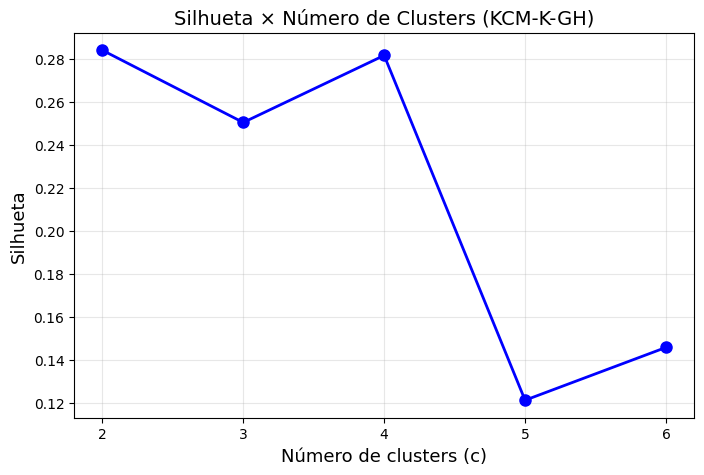


c* = 2 (Silhueta = 0.2841)


In [21]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
import matplotlib.pyplot as plt

def run_experiments_q1(X, y, c_values=[2,3,4,5,6], n_runs=100, gamma=1.0):
    results = {}

    for c in c_values:
        print(f"\n--- c = {c} ---")
        best_obj = np.inf
        best_result = None

        for run in range(n_runs):
            try:
                partition, prototypes, s2, obj_history = kcm_k_gh(X, c, gamma)

                # Verifica se todos clusters têm pelo menos 1 objeto
                if len(np.unique(partition)) < c:
                    continue

                final_obj = obj_history[-1]

                if final_obj < best_obj:
                    best_obj = final_obj
                    best_result = {
                        'partition': partition,
                        'prototypes': prototypes,
                        's2': s2,
                        'obj_history': obj_history,
                        'obj': final_obj
                    }
            except Exception as e:
                continue

        if best_result is not None:
            # Calcula silhueta
            try:
                sil = silhouette_score(X, best_result['partition'])
            except:
                sil = -1
            best_result['silhouette'] = sil
            results[c] = best_result
            print(f"  Melhor J = {best_obj:.4f}, Silhueta = {sil:.4f}")

    return results

# Executar
results = run_experiments_q1(X, y, n_runs=100, gamma=1.0)

# Plot Silhueta × c
c_vals = sorted(results.keys())
sil_vals = [results[c]['silhouette'] for c in c_vals]

plt.figure(figsize=(8, 5))
plt.plot(c_vals, sil_vals, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (c)', fontsize=13)
plt.ylabel('Silhueta', fontsize=13)
plt.title('Silhueta × Número de Clusters (KCM-K-GH)', fontsize=14)
plt.xticks(c_vals)
plt.grid(True, alpha=0.3)
plt.savefig('silhoueta_vs_c.png', dpi=150, bbox_inches='tight')
plt.show()

# Escolher c*
c_star = c_vals[np.argmax(sil_vals)]
print(f"\nc* = {c_star} (Silhueta = {max(sil_vals):.4f})")


ARI (c=2): 0.1456

i) Protótipos:
             var1  var2    var3    var4    var5    var6    var7    var8  \
Cluster 1  1.0000   0.0  0.8464  0.0087  0.8673  0.0031  0.8559  0.0064   
Cluster 2  0.9961   0.0  0.2543  0.0334  0.2102  0.0659  0.1484  0.0823   

             var9   var10  ...   var25   var26   var27   var28   var29  \
Cluster 1  0.8446 -0.0095  ...  0.7852 -0.0391  0.7914 -0.0206  0.7576   
Cluster 2  0.1582  0.0991  ...  0.0802  0.0046  0.1255 -0.0167  0.0295   

            var30   var31   var32   var33   var34  
Cluster 1 -0.0124  0.7649 -0.0224  0.7569 -0.0284  
Cluster 2 -0.0076  0.0541 -0.0166  0.0655 -0.0031  

[2 rows x 34 columns]

ii) Vetor s² (hiper-parâmetros de largura):
             s²
var1   0.024369
var2   0.000000
var3   1.360984
var4   0.679073
var5   1.100180
var6   0.758469
var7   0.905861
var8   1.173713
var9   0.933295
var10  0.629330
var11  1.119103
var12  0.852106
var13  0.818627
var14  0.777535
var15  0.923744
var16  0.869718
var17  1.083666
var1

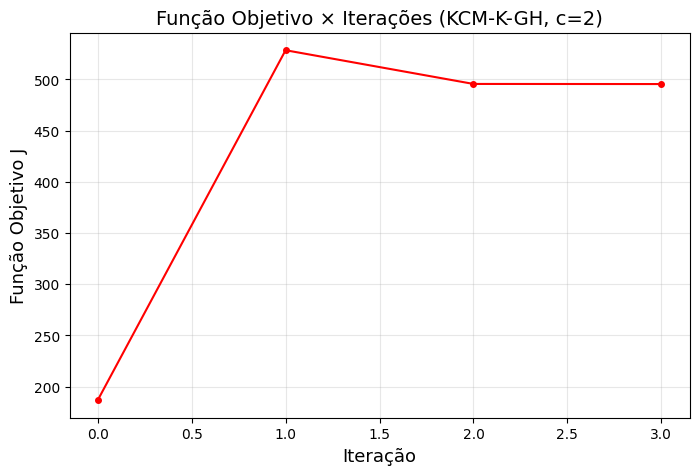

In [22]:
best = results[c_star]

# ARI (Rand Index Corrigido)
# Converter labels de string para int se necessário
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_int = le.fit_transform(y)

ari = adjusted_rand_score(y_int, best['partition'])
print(f"\nARI (c={c_star}): {ari:.4f}")

# i) Protótipos
print("\ni) Protótipos:")
proto_df = pd.DataFrame(best['prototypes'],
                         columns=[f'var{j+1}' for j in range(X.shape[1])])
proto_df.index = [f'Cluster {i+1}' for i in range(c_star)]
print(proto_df.round(4))

# ii) Vetor de hiper-parâmetros s
print("\nii) Vetor s² (hiper-parâmetros de largura):")
s2_df = pd.DataFrame({'s²': best['s2']},
                      index=[f'var{j+1}' for j in range(X.shape[1])])
print(s2_df.round(6))

# iii) Matriz de Confusão
# Como clustering não tem correspondência direta com classes,
# usamos Hungarian algorithm ou melhor mapeamento
from scipy.optimize import linear_sum_assignment

def best_mapping_confusion(y_true, y_pred, n_classes, n_clusters):
    """Encontra melhor mapeamento cluster→classe via Hungarian"""
    cost = np.zeros((n_clusters, n_classes))
    for i in range(n_clusters):
        for j in range(n_classes):
            cost[i, j] = -np.sum((y_pred == i) & (y_true == j))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = dict(zip(row_ind, col_ind))
    y_mapped = np.array([mapping.get(p, p) for p in y_pred])
    return y_mapped, mapping

n_classes = len(np.unique(y_int))
y_mapped, mapping = best_mapping_confusion(y_int, best['partition'],
                                            n_classes, c_star)

print("\niii) Matriz de Confusão:")
# The confusion_matrix will generate rows for all labels present in the union of y_int and y_mapped.
# Since np.unique(y_int) is [0,1] and np.unique(y_mapped) is [0,1,2],
# the default confusion_matrix will use labels [0,1,2] for both rows and columns, resulting in a (3,3) matrix.
# We only care about n_classes rows (which is 2 in this case, for y_int labels 0 and 1).
cm = confusion_matrix(y_int, y_mapped)

# Slice the confusion matrix to keep only the rows corresponding to actual classes in y_int
# n_classes is the number of unique true labels (which is 2: 'b' and 'g')
cm_display = cm[:n_classes, :] # This will result in a (2, 3) matrix

# Create column labels based on the actual unique values in y_mapped
predicted_cluster_labels = np.unique(y_mapped)
cm_columns = [f'Cluster→Class {p}' for p in predicted_cluster_labels]

# The index for the DataFrame should correspond to the true classes
cm_index = [f'Classe {le.classes_[i]}' for i in range(n_classes)]

print(pd.DataFrame(cm_display,
                    index=cm_index,
                    columns=cm_columns))

# iv) Plot função objetivo × iterações
plt.figure(figsize=(8, 5))
plt.plot(best['obj_history'], 'r-o', markersize=4)
plt.xlabel('Iteração', fontsize=13)
plt.ylabel('Função Objetivo J', fontsize=13)
plt.title(f'Função Objetivo × Iterações (KCM-K-GH, c={c_star})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('obj_vs_iter.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Versão 1: classes originais (2 classes: 'b' e 'g')
y_v1 = y_int.copy()  # 0 e 1

# Versão 2: classes = clusters do c* obtido na Q1
y_v2 = best['partition'].copy()

print(f"Versão 1: {np.unique(y_v1, return_counts=True)}")
print(f"Versão 2: {np.unique(y_v2, return_counts=True)}")

Versão 1: (array([0, 1]), array([126, 225]))
Versão 2: (array([0, 1]), array([181, 170]))


In [24]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
from scipy.stats import multivariate_normal

# ─── i) Classificador Bayesiano Gaussiano ─────────────────────────────────────

class GaussianBayesianClassifier(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = {}
        self.means_ = {}
        self.covs_ = {}

        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / len(X)
            self.means_[c] = Xc.mean(axis=0)
            # MV: divide por n (não n-1)
            cov = np.cov(Xc.T, bias=True)
            # Regularização para evitar singular
            cov += 1e-6 * np.eye(cov.shape[0])
            self.covs_[c] = cov
        return self

    def predict_proba(self, X):
        probs = np.zeros((len(X), len(self.classes_)))
        for j, c in enumerate(self.classes_):
            try:
                rv = multivariate_normal(mean=self.means_[c],
                                          cov=self.covs_[c],
                                          allow_singular=True)
                likelihood = rv.pdf(X)
            except:
                likelihood = np.ones(len(X)) * 1e-300
            probs[:, j] = likelihood * self.priors_[c]

        row_sums = probs.sum(axis=1, keepdims=True)
        row_sums = np.maximum(row_sums, 1e-300)
        return probs / row_sums

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

# ─── ii) Bayesiano k-NN ────────────────────────────────────────────────────────

class KNNBayesianClassifier(BaseEstimator, ClassifierMixin):
    """
    Bayesiano com densidade estimada por k-NN.
    p(x|ωi) ∝ k_i / (n_i * V_k(x))
    onde V_k(x) é o volume da bola de raio d_k
    """
    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.X_train_ = X
        self.y_train_ = y
        self.priors_ = {c: np.mean(y == c) for c in self.classes_}
        self.n_per_class_ = {c: np.sum(y == c) for c in self.classes_}
        return self

    def _distance(self, x1, x2):
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((x1 - x2)**2))
        elif self.metric == 'cityblock':
            return np.sum(np.abs(x1 - x2))
        elif self.metric == 'chebyshev':
            return np.max(np.abs(x1 - x2))

    def _density(self, x, class_c):
        Xc = self.X_train_[self.y_train_ == class_c]
        nc = len(Xc)
        if nc == 0:
            return 1e-300

        k = min(self.k, nc)
        dists = np.array([self._distance(x, xi) for xi in Xc])
        dists.sort()

        # Raio da k-ésima vizinhança
        r = dists[k-1] if k > 0 else 1e-10
        r = max(r, 1e-10)

        d = len(x)
        # Volume da bola d-dimensional: V = pi^(d/2) / Gamma(d/2+1) * r^d
        from scipy.special import gamma as gamma_func
        volume = (np.pi**(d/2) / gamma_func(d/2 + 1)) * (r**d)
        volume = max(volume, 1e-300)

        return k / (nc * volume)

    def predict(self, X):
        preds = []
        for x in X:
            posteriors = {}
            for c in self.classes_:
                density = self._density(x, c)
                posteriors[c] = density * self.priors_[c]
            preds.append(max(posteriors, key=posteriors.get))
        return np.array(preds)

# Versão sklearn-compatible para CV com hiper-parâmetro k e métrica
class KNNBayesianCV(BaseEstimator, ClassifierMixin):
    def __init__(self, k=5, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.clf_ = KNNBayesianClassifier(k=self.k, metric=self.metric)
        self.clf_.fit(X, y)
        return self

    def predict(self, X):
        return self.clf_.predict(X)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# ─── iii) Bayesiano Janela de Parzen ──────────────────────────────────────────

class ParzenBayesianClassifier(BaseEstimator, ClassifierMixin):
    """
    Kernel gaussiano univariado (produto) para cada dimensão.
    p(x|ωi) = (1/n_i) * Σ_k K_h(x - x_k)
    com K_h(u) = Π_j (1/h) * φ(u_j/h)
    """
    def __init__(self, h=1.0):
        self.h = h

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.X_train_ = X
        self.y_train_ = y
        self.priors_ = {c: np.mean(y == c) for c in self.classes_}
        return self

    def _kernel(self, x, xi, h):
        """Kernel gaussiano produto multivariado"""
        d = len(x)
        diff = (x - xi) / h
        return (1.0 / (np.sqrt(2*np.pi) * h))**d * np.exp(-0.5 * np.sum(diff**2))

    def _density(self, x, class_c):
        Xc = self.X_train_[self.y_train_ == class_c]
        nc = len(Xc)
        if nc == 0:
            return 1e-300
        density = np.mean([self._kernel(x, xi, self.h) for xi in Xc])
        return max(density, 1e-300)

    def predict(self, X):
        preds = []
        for x in X:
            posteriors = {c: self._density(x, c) * self.priors_[c]
                         for c in self.classes_}
            preds.append(max(posteriors, key=posteriors.get))
        return np.array(preds)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [25]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

def tune_hyperparameter_knn(X_train, y_train, k_values=[1,3,5,7,9,11,13,15],
                             metrics=['euclidean','cityblock','chebyshev']):
    """Valida cruzada 5-folds para k e métrica do k-NN"""
    best_score = -1
    best_k, best_metric = 5, 'euclidean'

    skf = StratifiedKFold(n_splits=5, shuffle=True)

    for k in k_values:
        for metric in metrics:
            scores = []
            for tr, va in skf.split(X_train, y_train):
                clf = KNNBayesianCV(k=k, metric=metric)
                clf.fit(X_train[tr], y_train[tr])
                scores.append(clf.score(X_train[va], y_train[va]))
            score = np.mean(scores)
            if score > best_score:
                best_score = score
                best_k = k
                best_metric = metric

    return best_k, best_metric

def tune_hyperparameter_parzen(X_train, y_train,
                                h_values=[0.01, 0.05, 0.1, 0.5, 1.0, 2.0]):
    """Valida cruzada 5-folds para h da janela de Parzen"""
    best_score = -1
    best_h = 0.5

    skf = StratifiedKFold(n_splits=5, shuffle=True)

    for h in h_values:
        scores = []
        for tr, va in skf.split(X_train, y_train):
            clf = ParzenBayesianClassifier(h=h)
            clf.fit(X_train[tr], y_train[tr])
            scores.append(clf.score(X_train[va], y_train[va]))
        score = np.mean(scores)
        if score > best_score:
            best_score = score
            best_h = h

    return best_h

def compute_metrics(y_true, y_pred, average='weighted'):
    """Calcula todas as métricas de avaliação"""
    err = 1.0 - accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    return {'error': err, 'precision': prec, 'recall': rec, 'f1': f1}

def run_30x10_cv(X, y, n_outer=30, n_inner=10):
    """
    Validação cruzada estratificada 30 × 10-folds.
    Para cada um dos 30 experimentos, faz 10-fold estratificado.
    Retorna métricas para cada classificador.
    """
    clf_names = ['Bayesiano Gaussiano', 'k-NN Bayesiano',
                 'Parzen Bayesiano', 'Reg. Logística', 'Voto Majoritário']

    all_metrics = {name: {'error':[], 'precision':[],
                          'recall':[], 'f1':[]}
                   for name in clf_names}

    for exp in range(n_outer):
        print(f"Experimento {exp+1}/{n_outer}...")
        skf_outer = StratifiedKFold(n_splits=n_inner, shuffle=True,
                                     random_state=exp)

        for fold, (train_idx, test_idx) in enumerate(skf_outer.split(X, y)):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # ─ i) Bayesiano Gaussiano ──────────────────
            clf_gauss = GaussianBayesianClassifier()
            clf_gauss.fit(X_train, y_train)
            y_pred_gauss = clf_gauss.predict(X_test)

            # ─ ii) k-NN Bayesiano (com ajuste de k e métrica) ──
            # Usa os 9 folds restantes para CV interna
            best_k, best_metric = tune_hyperparameter_knn(X_train, y_train)
            clf_knn = KNNBayesianCV(k=best_k, metric=best_metric)
            clf_knn.fit(X_train, y_train)
            y_pred_knn = clf_knn.predict(X_test)

            # ─ iii) Parzen ─────────────────────────────
            best_h = tune_hyperparameter_parzen(X_train, y_train)
            clf_parzen = ParzenBayesianClassifier(h=best_h)
            clf_parzen.fit(X_train, y_train)
            y_pred_parzen = clf_parzen.predict(X_test)

            # ─ iv) Regressão Logística ─────────────────
            from sklearn.model_selection import GridSearchCV
            lr = LogisticRegression(max_iter=1000, random_state=42)
            param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
            cv_lr = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy')
            cv_lr.fit(X_train, y_train)
            clf_lr = cv_lr.best_estimator_
            y_pred_lr = clf_lr.predict(X_test)

            # ─ v) Voto Majoritário ─────────────────────
            from scipy.stats import mode
            votes = np.stack([y_pred_gauss, y_pred_knn,
                              y_pred_parzen, y_pred_lr], axis=1)
            y_pred_vote = np.apply_along_axis(
                lambda x: mode(x, keepdims=True)[0][0], 1, votes)

            # ─ Calcular métricas ───────────────────────
            preds = [y_pred_gauss, y_pred_knn, y_pred_parzen,
                     y_pred_lr, y_pred_vote]

            for name, y_pred in zip(clf_names, preds):
                avg = 'binary' if len(np.unique(y)) == 2 else 'weighted'
                m = compute_metrics(y_test, y_pred, average=avg)
                for metric, val in m.items():
                    all_metrics[name][metric].append(val)

    return all_metrics

In [26]:
from scipy import stats

def confidence_interval(data, confidence=0.95):
    """IC usando t-Student (n pequeno) ou normal"""
    n = len(data)
    mean = np.mean(data)
    se = stats.sem(data)
    ci = stats.t.interval(confidence, df=n-1, loc=mean, scale=se)
    return mean, ci[0], ci[1]

def summarize_metrics(all_metrics):
    """Tabela com estimativas pontuais e ICs"""
    results = []
    for clf_name, metrics in all_metrics.items():
        row = {'Classificador': clf_name}
        for metric, values in metrics.items():
            mean, ci_low, ci_high = confidence_interval(values)
            row[f'{metric}_mean'] = round(mean, 4)
            row[f'{metric}_CI'] = f"[{ci_low:.4f}, {ci_high:.4f}]"
        results.append(row)
    return pd.DataFrame(results)

In [27]:
from scipy.stats import friedmanchisquare

def friedman_nemenyi_test(all_metrics, metric='f1'):
    """
    Teste de Friedman para comparação múltipla de classificadores.
    Pós-teste de Nemenyi.
    """
    clf_names = list(all_metrics.keys())

    # Matriz: cada linha = uma observação (fold), cada coluna = um classificador
    data = np.array([all_metrics[clf][metric] for clf in clf_names]).T

    # Teste de Friedman
    stat, p_value = friedmanchisquare(*[data[:, j] for j in range(data.shape[1])])
    print(f"\n=== Friedman Test ({metric}) ===")
    print(f"Estatística: {stat:.4f}, p-value: {p_value:.6f}")

    if p_value < 0.05:
        print("→ Rejeita H0: há diferença significativa entre os classificadores")

        # Pós-teste de Nemenyi
        # pip install scikit-posthocs
        try:
            import scikit_posthocs as sp
            nemenyi = sp.posthoc_nemenyi_friedman(data)
            nemenyi.columns = clf_names
            nemenyi.index = clf_names
            print("\n=== Nemenyi Post-hoc p-values ===")
            print(nemenyi.round(4))
        except ImportError:
            print("Instale scikit-posthocs: pip install scikit-posthocs")
    else:
        print("→ Não rejeita H0: sem diferença significativa")

    return stat, p_value

In [28]:
def plot_learning_curves(X, y, clf_names_dict, metric='f1'):
    """
    Curvas de aprendizado: variam o tamanho do conjunto de treinamento
    de 5% a 95% com passo de 5%.
    """
    train_sizes = np.arange(0.05, 1.00, 0.05)

    fig, axes = plt.subplots(len(clf_names_dict), 1,
                              figsize=(10, 5*len(clf_names_dict)))
    if len(clf_names_dict) == 1:
        axes = [axes]

    avg = 'binary' if len(np.unique(y)) == 2 else 'weighted'

    for ax, (clf_name, clf_class) in zip(axes, clf_names_dict.items()):
        train_scores, test_scores = [], []

        for train_frac in train_sizes:
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

            tr_s, te_s = [], []
            for train_idx, test_idx in skf.split(X, y):
                # Seleciona fração do conjunto de treinamento
                n_train = max(2, int(len(train_idx) * train_frac))
                train_sub = train_idx[:n_train]

                try:
                    clf = clf_class()
                    clf.fit(X[train_sub], y[train_sub])

                    y_tr = clf.predict(X[train_sub])
                    y_te = clf.predict(X[test_idx])

                    tr_s.append(f1_score(y[train_sub], y_tr,
                                         average=avg, zero_division=0))
                    te_s.append(f1_score(y[test_idx], y_te,
                                         average=avg, zero_division=0))
                except:
                    continue

            train_scores.append(np.mean(tr_s) if tr_s else 0)
            test_scores.append(np.mean(te_s) if te_s else 0)

        ax.plot(train_sizes*100, train_scores, 'b-o',
                label='Treinamento', markersize=5)
        ax.plot(train_sizes*100, test_scores, 'r-o',
                label='Teste', markersize=5)
        ax.set_xlabel('% Conjunto de Treinamento', fontsize=12)
        ax.set_ylabel('F-measure', fontsize=12)
        ax.set_title(f'Curva de Aprendizado — {clf_name}', fontsize=13)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('curvas_aprendizado.png', dpi=150, bbox_inches='tight')
    plt.show()

QUESTÃO 1 — KCM-K-GH no Dataset Ionosphere

--- c = 2 ---
  Melhor J = 495.4454, Silhueta = 0.2841

--- c = 3 ---
  Melhor J = 467.6262, Silhueta = 0.2111

--- c = 4 ---
  Melhor J = 461.3550, Silhueta = 0.2368

--- c = 5 ---
  Melhor J = 436.1843, Silhueta = 0.1229

--- c = 6 ---
  Melhor J = 415.8734, Silhueta = 0.1439

c* = 2
ARI = 0.1456

QUESTÃO 2 — Classificadores Bayesianos

──────────────────────────────────────────────────
Versão 1 (2 classes originais)
──────────────────────────────────────────────────
Experimento 1/30...
Experimento 2/30...
Experimento 3/30...
Experimento 4/30...
Experimento 5/30...
Experimento 6/30...
Experimento 7/30...
Experimento 8/30...
Experimento 9/30...
Experimento 10/30...
Experimento 11/30...
Experimento 12/30...
Experimento 13/30...
Experimento 14/30...
Experimento 15/30...
Experimento 16/30...
Experimento 17/30...
Experimento 18/30...
Experimento 19/30...
Experimento 20/30...
Experimento 21/30...
Experimento 22/30...
Experimento 23/30...
Experime

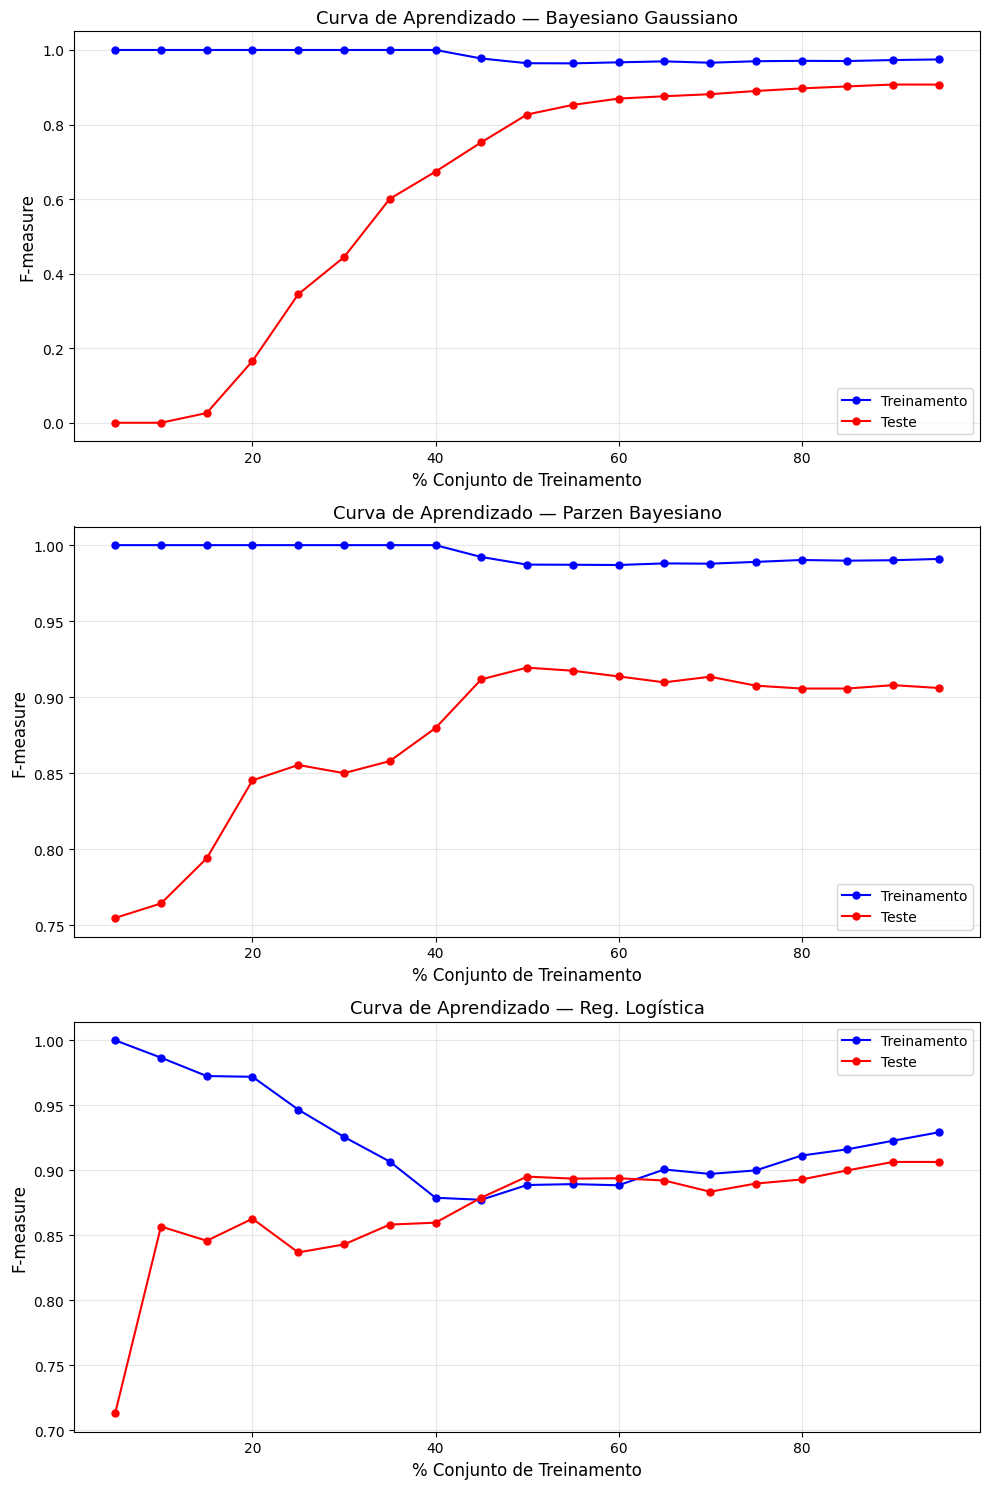


──────────────────────────────────────────────────
Versão 2 (2 clusters de Q1)
──────────────────────────────────────────────────
Experimento 1/30...
Experimento 2/30...
Experimento 3/30...
Experimento 4/30...
Experimento 5/30...
Experimento 6/30...
Experimento 7/30...
Experimento 8/30...
Experimento 9/30...
Experimento 10/30...
Experimento 11/30...
Experimento 12/30...
Experimento 13/30...
Experimento 14/30...
Experimento 15/30...
Experimento 16/30...
Experimento 17/30...
Experimento 18/30...
Experimento 19/30...
Experimento 20/30...
Experimento 21/30...
Experimento 22/30...
Experimento 23/30...
Experimento 24/30...
Experimento 25/30...
Experimento 26/30...
Experimento 27/30...
Experimento 28/30...
Experimento 29/30...
Experimento 30/30...

b) Estimativas e Intervalos de Confiança:
      Classificador  error_mean         error_CI  precision_mean     precision_CI  recall_mean        recall_CI  f1_mean            f1_CI
Bayesiano Gaussiano      0.1478 [0.1408, 0.1547]          0.8806 [0

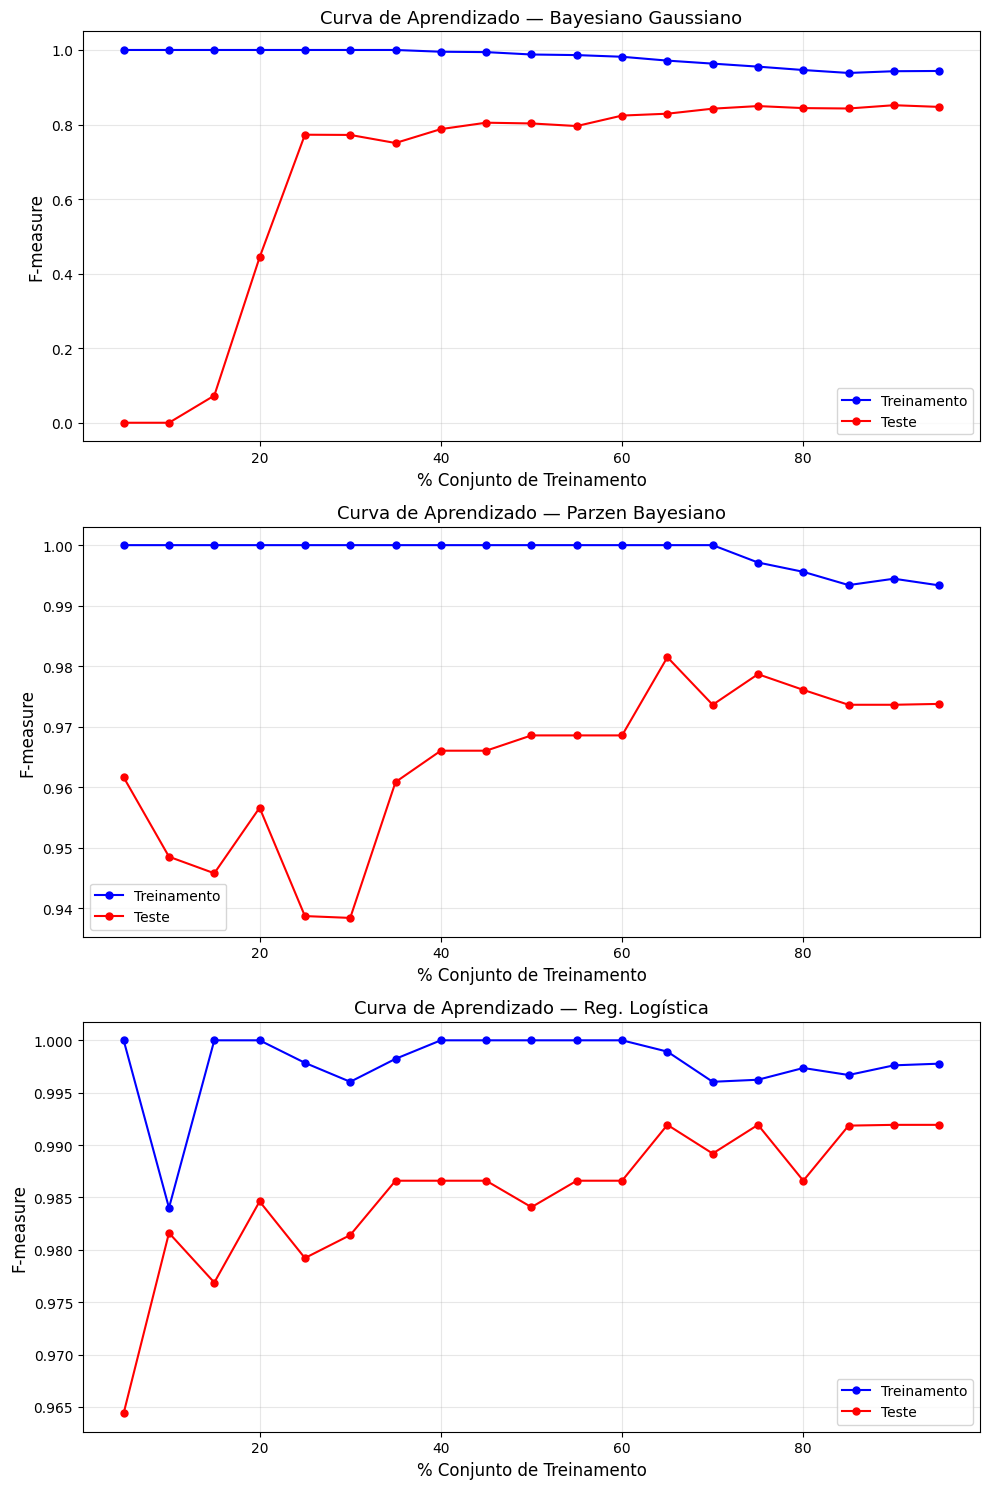

In [29]:
# main.py
if __name__ == '__main__':

    # ═══════════════════════════════════════════════
    # QUESTÃO 1
    # ═══════════════════════════════════════════════
    print("=" * 60)
    print("QUESTÃO 1 — KCM-K-GH no Dataset Ionosphere")
    print("=" * 60)

    results_q1 = run_experiments_q1(X, y, c_values=[2,3,4,5,6],
                                     n_runs=100, gamma=1.0)

    # Escolher c*
    c_vals = sorted(results_q1.keys())
    sil_vals = [results_q1[c]['silhouette'] for c in c_vals]
    c_star = c_vals[np.argmax(sil_vals)]
    best = results_q1[c_star]

    print(f"\nc* = {c_star}")

    # ARI
    le = LabelEncoder()
    y_int = le.fit_transform(y)
    ari = adjusted_rand_score(y_int, best['partition'])
    print(f"ARI = {ari:.4f}")

    # ═══════════════════════════════════════════════
    # QUESTÃO 2
    # ═══════════════════════════════════════════════
    print("\n" + "=" * 60)
    print("QUESTÃO 2 — Classificadores Bayesianos")
    print("=" * 60)

    for version, y_target, label in [
        (1, y_int, "Versão 1 (2 classes originais)"),
        (2, best['partition'], f"Versão 2 ({c_star} clusters de Q1)")
    ]:
        print(f"\n{'─'*50}")
        print(f"{label}")
        print('─'*50)

        # 30x10-fold CV
        all_metrics = run_30x10_cv(X, y_target, n_outer=30, n_inner=10)

        # b) Estimativas + IC
        summary = summarize_metrics(all_metrics)
        print("\nb) Estimativas e Intervalos de Confiança:")
        print(summary.to_string(index=False))

        # c) Friedman + Nemenyi
        for metric in ['error', 'precision', 'recall', 'f1']:
            friedman_nemenyi_test(all_metrics, metric=metric)

        # d) Curvas de aprendizado (F-measure)
        clf_dict = {
            'Bayesiano Gaussiano': GaussianBayesianClassifier,
            'Parzen Bayesiano': lambda: ParzenBayesianClassifier(h=0.5),
            'Reg. Logística': lambda: LogisticRegression(max_iter=1000)
        }
        plot_learning_curves(X, y_target, clf_dict, metric='f1')